<a href="https://colab.research.google.com/github/AdityaAgrawal08/Airline_Customer_Tweets_Analysis/blob/main/FDS_Assignment(Updated).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries (run once in Colab)
!pip install nltk

Title:

Airline Customer Tweets

Objective

To analyze airline-related Twitter data and identify customer sentiment patterns using text mining techniques, visualization, and machine learning–based sentiment classification.

Import Libraries ->

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Load Dataset ->

In [3]:
url="https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/refs/heads/master/Tweets.csv"

data = pd.read_csv(url)

Sentiment Distribution Graph ->

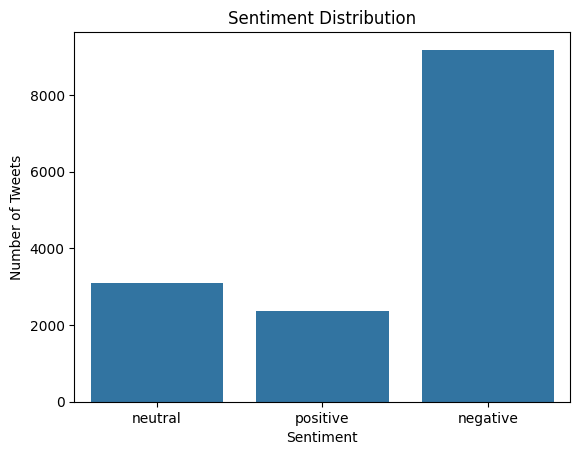

In [4]:
plt.figure()
sns.countplot(x=data['airline_sentiment'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

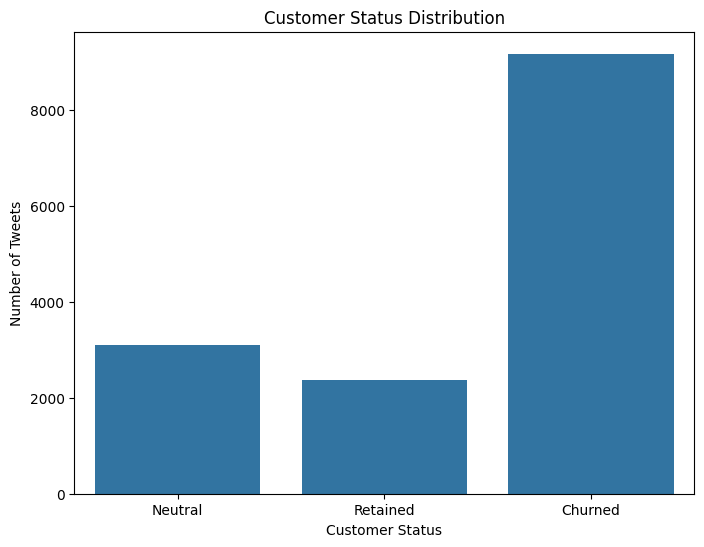

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def churn_category(sentiment):
    if sentiment == "negative":
        return "Churned"
    elif sentiment == "positive":
        return "Retained"
    else:
        return "Neutral"

data["customer_status"] = data["airline_sentiment"].apply(churn_category)

plt.figure(figsize=(8, 6))
sns.countplot(x=data['customer_status'])
plt.title("Customer Status Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Tweets")
plt.show()

Airline Wise Tweet Count ->

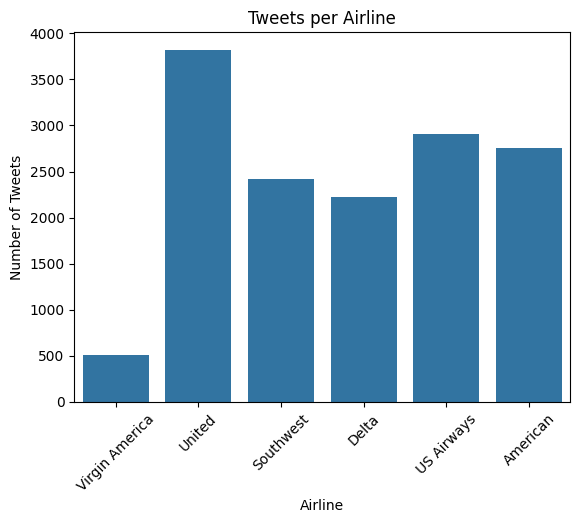

In [6]:
plt.figure()
sns.countplot(x=data['airline'])
plt.title("Tweets per Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.show()

Airline vs Sentiment Graph ->

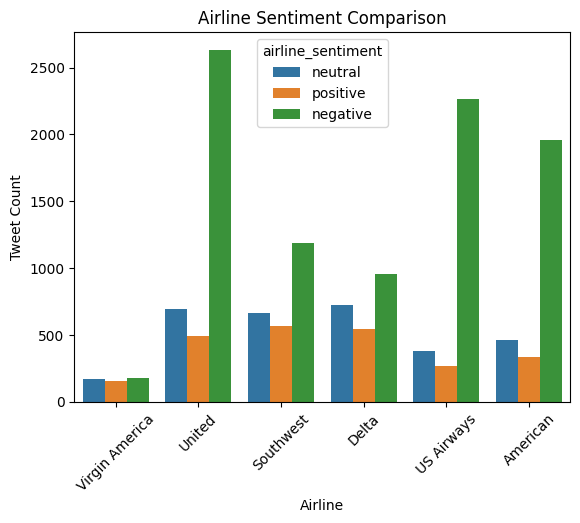

In [7]:
plt.figure()
sns.countplot(data=data, x='airline', hue='airline_sentiment')
plt.title("Airline Sentiment Comparison")
plt.xlabel("Airline")
plt.ylabel("Tweet Count")
plt.xticks(rotation=45)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X = data['text']
y = data['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

vectorizer = TfidfVectorizer(stop_words='english')

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Predictions ->

In [10]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.80      0.93      0.86      1832
     neutral       0.65      0.47      0.55       611
    positive       0.80      0.59      0.68       485

    accuracy                           0.78      2928
   macro avg       0.75      0.66      0.70      2928
weighted avg       0.77      0.78      0.77      2928



Confusion Matrix Graph ->

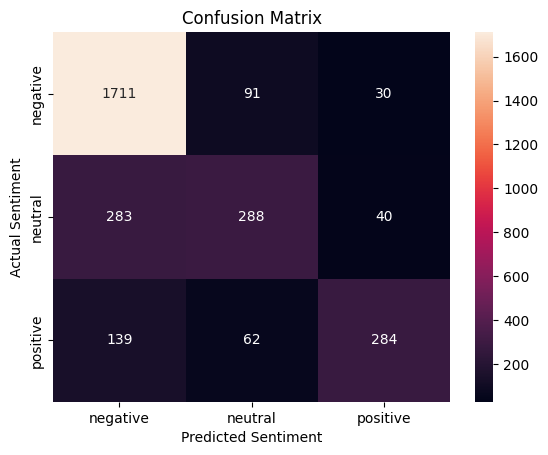

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")
plt.show()

Conclusionary Analysis Code ->

In [12]:

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nActual Sentiment Distribution:")
print(result["Actual"].value_counts())
print("\nPredicted Sentiment Distribution:")
print(result["Predicted"].value_counts())


Model Accuracy: 0.7797131147540983

Actual Sentiment Distribution:
Actual
negative    1832
neutral      611
positive     485
Name: count, dtype: int64

Predicted Sentiment Distribution:
Predicted
negative    2133
neutral      441
positive     354
Name: count, dtype: int64


Conclusion

The analysis shows that most airline-related tweets express negative sentiment. The machine learning model successfully classifies tweets into positive, neutral, and negative categories, helping identify customer opinion patterns.